# s**I**n**A**pse

# Regressao Linear Simples: Previsao de Crescimento de um App de Corridas

**Objetivo da Atividade:** Aplicar regressao linear simples para modelar o crescimento diario de um aplicativo de mobilidade urbana, avaliar a qualidade do modelo com as metricas R2, MAE, MSE e RMSE, e usar o modelo para estimar quando sera necessario escalar a infraestrutura de servidores.

In [20]:
# 1. IMPORTACAO DAS BIBLIOTECAS
import numpy as np                   # operacoes numericas e algebra linear
import pandas as pd                  # leitura e manipulacao de dados tabulares
import matplotlib.pyplot as plt      # criacao de graficos
import matplotlib.dates as mdates    # formatacao de datas nos eixos
from datetime import timedelta       # para somar dias a objetos datetime
from pathlib import Path             # manipulacao de caminhos de arquivo

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## Carregamento e Inspecao dos Dados

O dataset `rides_app.csv` contem **180 dias** de registros simulados de uso do aplicativo, com duas colunas:
- `date` a data do registro
- `rides_count` total de corridas realizadas naquele dia

Ajuste o caminho abaixo conforme a organizacao do seu projeto.

In [21]:
# 2. CARREGAMENTO DOS DADOS
PATH_CSV = Path("data/rides_app.csv")

df = pd.read_csv(PATH_CSV)

print("Primeiras linhas do dataset:")
df.head()

Primeiras linhas do dataset:


,date,rides_count
0,2025-01-01,5993
1,2025-01-02,4973
2,2025-01-03,6795
3,2025-01-04,8796
4,2025-01-05,5531


In [22]:
# Informacoes gerais: tipos de dado, linhas, colunas e valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         180 non-null    str  
 1   rides_count  180 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.9 KB


In [23]:
# Estatisticas descritivas: media, desvio padrao, minimo, maximo e quartis
df.describe()

,rides_count
count,180.000000
mean,27330.238889
std,13397.592570
min,4423.000000
25%,15588.500000
50%,27500.500000
75%,38208.250000
max,55190.000000


## Pre-processamento: Criando a Feature Temporal

A regressao linear trabalha com numeros, nao com strings de data.
Por isso, convertemos a coluna `date` e criamos a variavel `days_since_launch`:
um contador de dias a partir do dia 0 (data de lancamento do app).

Essa variavel sera a nossa **feature (X)** no modelo.

In [24]:
# 3. PRE-PROCESSAMENTO
# Converter a coluna 'date' de string para o tipo datetime
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

# Ordenar cronologicamente para garantir que o dia 0 seja o mais antigo
df = df.sort_values("date").reset_index(drop=True)

# Identificar o dia zero: a data mais antiga no dataset
dia_zero = df["date"].min()
print(f"Data de lancamento (dia 0): {dia_zero.date()}")

# Criar a feature: numero de dias corridos desde o lancamento
# .dt.days converte um timedelta para inteiro
df["days_since_launch"] = (df["date"] - dia_zero).dt.days

df.head()

Data de lancamento (dia 0): 2025-01-01


,date,rides_count,days_since_launch
0,2025-01-01,5993,0
1,2025-01-02,4973,1
2,2025-01-03,6795,2
3,2025-01-04,8796,3
4,2025-01-05,5531,4


## Visualizacao Exploratoria

Antes de ajustar qualquer modelo, visualizamos os dados brutos para identificar a tendencia geral, sazonalidades ou anomalias.

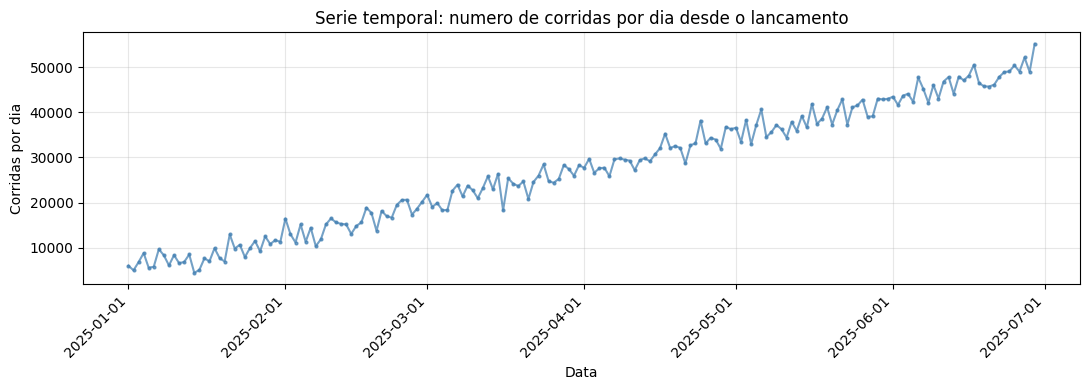

In [25]:
# 4. GRAFICO EXPLORATORIO
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df["date"], df["rides_count"], ".-", alpha=0.75, markersize=4, color="steelblue")

ax.set_xlabel("Data")
ax.set_ylabel("Corridas por dia")
ax.set_title("Serie temporal: numero de corridas por dia desde o lancamento")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preparacao das Matrizes X e y

Para aplicar a **Equacao Normal**, organizamos os dados em matrizes:

- `X` dias desde o lancamento (shape: n x 1)
- `y` numero de corridas por dia (shape: n,)
- `X_b` matriz aumentada com uma coluna de 1s para o intercepto B0

A coluna de 1s garante que a multiplicacao matricial inclua automaticamente o termo constante B0, evitando a necessidade de trata-lo separadamente.

In [26]:
# 5. MONTAGEM DAS MATRIZES
# Feature: dias desde o lancamento - reshape para coluna (n, 1)
X = df["days_since_launch"].to_numpy().reshape(-1, 1)

# Target: numero de corridas por dia
y = df["rides_count"].to_numpy()

n = len(y)

print(f"Observacoes (n): {n}")
print(f"Shape de X:      {X.shape}")
print(f"Shape de y:      {y.shape}")

Observacoes (n): 180
Shape de X:      (180, 1)
Shape de y:      (180,)


In [27]:
# Montar X_b: inserir coluna de 1s a esquerda de X
# np.ones cria o vetor de 1s | np.hstack concatena horizontalmente
X_b = np.hstack([np.ones((n, 1)), X])

print("Primeiras linhas de X_b  [coluna de 1s | days_since_launch]:")
print(X_b[:5, :])

Primeiras linhas de X_b  [coluna de 1s | days_since_launch]:
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]


## Ajuste do Modelo: Equacao Normal

A Equacao Normal resolve analiticamente o problema de minimos quadrados, encontrando os parametros que **minimizam a soma dos erros ao quadrado (SSE)**:

beta = (X_b^T * X_b)^-1 * X_b^T * y

Usamos `np.linalg.solve` no lugar da inversao direta `np.linalg.inv` por ser numericamente mais estavel e eficiente.

In [28]:
# 6. CALCULO DOS PARAMETROS (EQUACAO NORMAL)
# Resolve o sistema: (X_b.T @ X_b) @ beta = X_b.T @ y
beta = np.linalg.solve(X_b.T @ X_b, X_b.T @ y)

beta0 = beta[0]   # intercepto: corridas estimadas no dia 0
beta1 = beta[1]   # coeficiente angular: crescimento medio de corridas por dia

print("Parametros ajustados pelo modelo:")
print(f"  B0 (intercepto)     = {beta0:,.2f}  -> corridas estimadas no dia de lancamento")
print(f"  B1 (coef. angular)  = {beta1:.2f}  -> crescimento medio de corridas por dia")
print()
print(f"Equacao: corridas = {beta0:.2f} + {beta1:.2f} x days_since_launch")

Parametros ajustados pelo modelo:
  B0 (intercepto)     = 4,546.69  -> corridas estimadas no dia de lancamento
  B1 (coef. angular)  = 254.56  -> crescimento medio de corridas por dia

Equacao: corridas = 4546.69 + 254.56 x days_since_launch


In [29]:
# Calcular as previsoes para todos os pontos do dataset
y_pred = X_b @ beta

## Avaliacao do Modelo com Metricas de Regressao

Quatro metricas avaliam a qualidade do ajuste:

| Metrica | O que mede |
|--------|------------|
| **R2** | Proporcao da variancia explicada pelo modelo (0 a 1) |
| **MAE** | Erro medio absoluto (mesma unidade do target) |
| **MSE** | Penaliza erros grandes; sensivel a outliers |
| **RMSE** | Raiz do MSE, retorna a unidade original |

In [30]:
# 7. METRICAS DE AVALIACAO
# R2 - coeficiente de determinacao
ss_res = np.sum((y - y_pred) ** 2)    # variacao nao explicada (residuos)
ss_tot = np.sum((y - y.mean()) ** 2)  # variacao total dos dados
r2 = 1 - ss_res / ss_tot

# MAE - erro absoluto medio
mae = np.mean(np.abs(y - y_pred))

# MSE - erro quadratico medio
mse = np.mean((y - y_pred) ** 2)

# RMSE - raiz do erro quadratico medio
rmse = np.sqrt(mse)

print("=" * 50)
print("METRICAS DE AVALIACAO DO MODELO")
print("=" * 50)
print(f"R2   = {r2:.4f}")
print(f"MAE  = {mae:,.2f} corridas/dia")
print(f"MSE  = {mse:,.2f} (corridas/dia)^2")
print(f"RMSE = {rmse:,.2f} corridas/dia")
print()
print("Interpretacao:")
print(f"  -> R2 = {r2:.3f}: o modelo explica {r2*100:.1f}% da variacao diaria no numero de corridas.")
print(f"  -> MAE aprox {mae:.0f}: em media, o modelo erra cerca de {mae:.0f} corridas por dia.")
print(f"  -> RMSE aprox {rmse:.0f}: o erro tipico e de aproximadamente {rmse:.0f} corridas/dia.")

METRICAS DE AVALIACAO DO MODELO
R2   = 0.9802
MAE  = 1,482.80 corridas/dia
MSE  = 3,534,956.81 (corridas/dia)^2
RMSE = 1,880.15 corridas/dia

Interpretacao:
  -> R2 = 0.980: o modelo explica 98.0% da variacao diaria no numero de corridas.
  -> MAE aprox 1483: em media, o modelo erra cerca de 1483 corridas por dia.
  -> RMSE aprox 1880: o erro tipico e de aproximadamente 1880 corridas/dia.


## Visualizacao: Dados Reais vs. Reta de Regressao

O grafico sobrepos os dados originais (pontos) com a reta ajustada pelo modelo (linha vermelha). Um bom ajuste mantem a reta proxima dos pontos sem se afastar excessivamente.

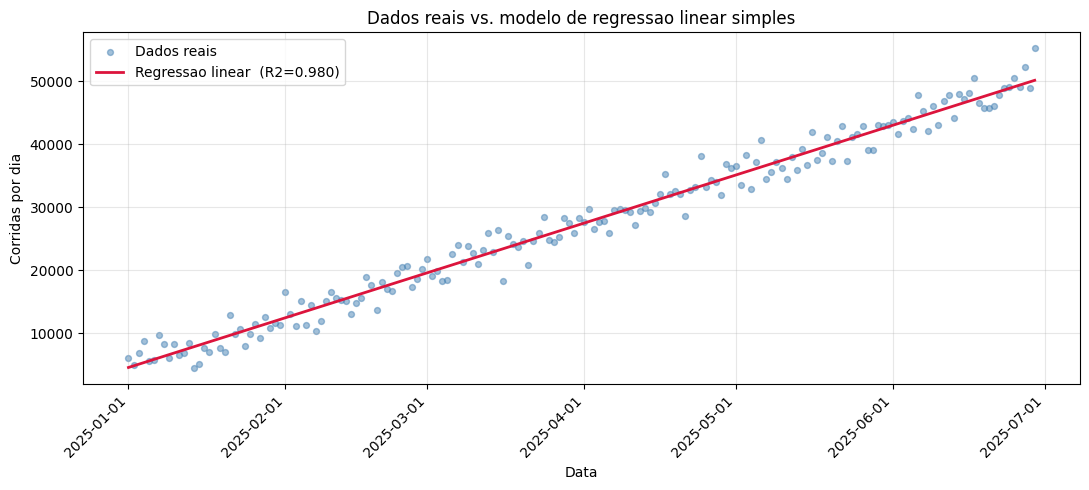

In [31]:
# 8. GRAFICO: DADOS REAIS vs. MODELO
fig, ax = plt.subplots(figsize=(11, 5))

ax.scatter(df["date"], y, alpha=0.5, s=18, label="Dados reais", color="steelblue")
ax.plot(df["date"], y_pred, color="crimson", linewidth=2, label=f"Regressao linear  (R2={r2:.3f})")

ax.set_xlabel("Data")
ax.set_ylabel("Corridas por dia")
ax.set_title("Dados reais vs. modelo de regressao linear simples")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Planejamento de Capacidade: Quando Escalar os Servidores?

Com o modelo ajustado, resolvemos a equacao ao contrario: dado um **limite de capacidade** de corridas por dia, calculamos **em qual data** o app vai ultrapassa-lo.

t_limite = (corridas_limite - B0) / B1

Isso permite planejar o escalonamento de infraestrutura (ex.: AWS Auto Scaling) com antecedencia.

In [32]:
# 9. PLANEJAMENTO DE CAPACIDADE
# ---------------------------------------------------------------------------
# Ajuste o valor abaixo conforme a capacidade real do seu servidor
# ---------------------------------------------------------------------------
capacity_per_instance = 40_000    # corridas/dia suportadas por uma instancia

# Resolver a equacao para encontrar o dia t em que o limite e atingido
t_limite = (capacity_per_instance - beta0) / beta1

# Converter dias desde o lancamento para data de calendario
date_limite = dia_zero + timedelta(days=t_limite)

print("=" * 55)
print("PLANEJAMENTO DE CAPACIDADE DE INFRAESTRUTURA")
print("=" * 55)
print(f"  Capacidade maxima por instancia  : {capacity_per_instance:,} corridas/dia")
print(f"  Dias ate atingir o limite        : {t_limite:.1f} dias")
print(f"  Data estimada para escalonamento : {date_limite.date()}")
print()
print("Recomendacao: iniciar o planejamento pelo menos 2 a 4 semanas antes.")

PLANEJAMENTO DE CAPACIDADE DE INFRAESTRUTURA
  Capacidade maxima por instancia  : 40,000 corridas/dia
  Dias ate atingir o limite        : 139.3 dias
  Data estimada para escalonamento : 2025-05-20

Recomendacao: iniciar o planejamento pelo menos 2 a 4 semanas antes.


## Planejamento Conservador (Margem de Seguranca)

Na pratica, e prudente **escalar antes de atingir 100% da capacidade**. Usar 80% como gatilho deixa margem para picos inesperados de demanda e para o tempo de provisionamento dos novos recursos.

In [33]:
# 10. PLANEJAMENTO CONSERVADOR - 80% DA CAPACIDADE
margem_seguranca = 0.80
limite_conservador = capacity_per_instance * margem_seguranca

t_conservador = (limite_conservador - beta0) / beta1
date_conservador = dia_zero + timedelta(days=t_conservador)

print(f"Com margem de seguranca de {int(margem_seguranca * 100)}%:")
print(f"  -> Limite conservador : {limite_conservador:,.0f} corridas/dia")
print(f"  -> Data para agir     : {date_conservador.date()}")
print()
print(f"  Antecedencia em relacao ao limite total: {(date_limite - date_conservador).days} dias")

Com margem de seguranca de 80%:
  -> Limite conservador : 32,000 corridas/dia
  -> Data para agir     : 2025-04-18

  Antecedencia em relacao ao limite total: 31 dias


**CONCLUSAO**

## Conclusao

Neste projeto aplicamos regressao linear simples para modelar o crescimento diario de corridas em um app de mobilidade urbana. Seguindo as etapas de pre-processamento, montagem matricial e calculo pela Equacao Normal, obtivemos os parametros B0 e B1 sem uso de bibliotecas de ML, apenas com NumPy.

As metricas de avaliacao confirmaram a qualidade do ajuste, e o modelo foi usado de forma invertida para estimar a data em que sera necessario escalar a infraestrutura de servidores, com e sem margem de seguranca.

Mais do que obter boas metricas, o exercicio mostrou como um modelo simples pode gerar valor pratico real: transformar dados historicos em uma decisao de infraestrutura com data definida.

### Limitacoes e proximos passos

- A regressao linear assume crescimento constante; na pratica, apps crescem de forma nao linear
- Nao captura sazonalidade como fins de semana, feriados ou promocoes
- **Extensoes possiveis:** Regressao Polinomial, features de calendario, Random Forest, XGBoost ou Prophet para series temporais com sazonalidade

---
*Dataset sintetico gerado para fins educacionais.*